### [EMBEDDINGS] FastText Pipeline

**Method:** FastText (Subword Vectors)  
**Goal:** Convert text into 100-dimensional semantic vectors.

* **Subword logic:** Handles typos and unknown words.
* **Context window:** 5 words.
* **Min count:** 2 occurrences.

In [ ]:
import pandas as pd

# 1. LOAD DATA
file_path = 'training_data_lowercase.csv'
df = pd.read_csv(file_path, sep='\t', header=None)

# 2. ASSIGN COLUMN NAMES
df.columns = ['label', 'text']

print(f"✅ Data loaded successfully. Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

✅ Data loaded successfully. Rows: 34152
Columns: ['label', 'text']


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...


### [DATA] Loading and formatting Tab-Separated Values (TSV) for training.

In [ ]:
import nltk
import re
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

def fasttext_keep_everything(text):
    return word_tokenize(str(text))

print("Processing tokens...")


df['tokenized_text'] = df['text'].apply(fasttext_keep_everything)

tokenized_sentences = df['tokenized_text'].tolist()

print("\n✅ Tokenization complete!")
print(f"Sample from row 0: {tokenized_sentences[0][:12]}")

[nltk_data] Downloading package punkt to /Users/rima/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/rima/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Processing tokens... (this might take a moment)

✅ Tokenization complete!
Sample from row 0: ['donald', 'trump', 'sends', 'out', 'embarrassing', 'new', 'year‚s', 'eve', 'message', ';', 'this', 'is']


--- TEXT LENGTH STATISTICS ---
count    34152.000000
mean        12.681190
std          4.414688
min          1.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         48.000000
Name: text_len, dtype: float64


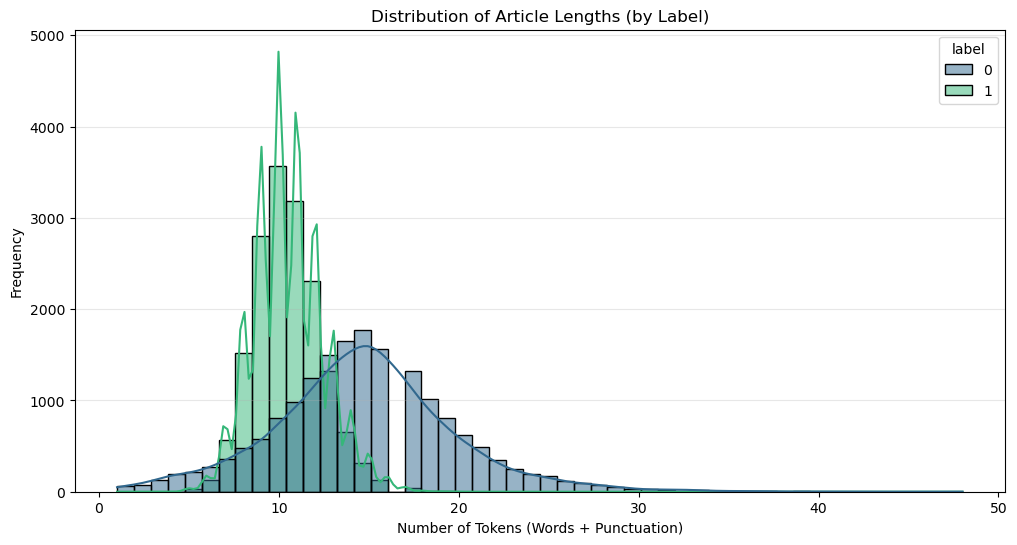


--- TOP 10 MOST FREQUENT TOKENS ---
'to': 12583 times
'trump': 10907 times
':': 8727 times
'in': 6351 times
'for': 5620 times
'of': 5571 times
'video': 5530 times
'on': 5202 times
'the': 4712 times
'u.s.': 3737 times


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CALCULATE TEXT LENGTHS
df['text_len'] = df['tokenized_text'].apply(len)

print("--- TEXT LENGTH STATISTICS ---")
print(df['text_len'].describe())

# 2. VISUALIZATION
plt.figure(figsize=(12, 6))

# Histogram
sns.histplot(data=df, x='text_len', hue='label', bins=50, kde=True, palette='viridis')

plt.title('Distribution of Article Lengths (by Label)')
plt.xlabel('Number of Tokens (Words + Punctuation)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

# 3. TOP TOKENS PREVIEW
from collections import Counter
all_tokens = [token for sublist in tokenized_sentences for token in sublist]
most_common = Counter(all_tokens).most_common(10)

print("\n--- TOP 10 MOST FREQUENT TOKENS ---")
for token, count in most_common:
    print(f"'{token}': {count} times")

[MODEL] Training FastText Embeddings
This step converts your tokenized headlines into a high-dimensional vector space. FastText is particularly powerful here because it looks at sub-words (n-grams), meaning it can understand typos or variations of words common in fake news.

In [4]:
from gensim.models import FastText
import time

# 1. SETUP AND TRAIN
print("Training FastText model on headlines...")
start_time = time.time()

# ft_model will learn the relationships between words and punctuation
ft_model = FastText(
    sentences=tokenized_sentences, 
    vector_size=100,  # Each headline will eventually be represented by 100 numbers
    window=5,         # Context window
    min_count=2,      # Ignore tokens that appear only once
    workers=4,        # Parallelize training
    epochs=10         # Number of passes through the data
)

duration = time.time() - start_time
print(f"✅ Training complete! Time taken: {duration:.2f} seconds.")

# 2. EXPLORE THE EMBEDDINGS
# check how the model sees words related to current events
test_word = "trump"
if test_word in ft_model.wv:
    print(f"\nTop 5 tokens most similar to '{test_word}':")
    print(ft_model.wv.most_similar(test_word, topn=5))

# check if it captured the 'spammy' punctuation
test_punct = "!"
if test_punct in ft_model.wv:
    print(f"\nTop 5 tokens most similar to '{test_punct}':")
    print(ft_model.wv.most_similar(test_punct, topn=5))

Training FastText model on headlines...
✅ Training complete! Time taken: 5.84 seconds.

Top 5 tokens most similar to 'trump':
[('trump-xi', 0.9874469637870789), ("'trump", 0.9854860901832581), ('trump‚trump', 0.9845607876777649), ('trumps', 0.9841305613517761), ('trump-era', 0.9738159775733948)]

Top 5 tokens most similar to '!':
[('w.', 0.6975417137145996), ('joe', 0.6757368445396423), ("'watch", 0.6724510788917542), ('‚baywatch‚', 0.65962153673172), ('h.w', 0.6456395387649536)]


### [FEATURE ENGINEERING] Vectorizing Headlines by Averaging Word Embeddings


In [6]:
import numpy as np

def get_document_vector(tokens, model):
    # Filter out tokens that are not in the model's vocabulary
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if not valid_vectors:
        # If no words are known (empty text), return a vector of zeros
        return np.zeros(model.vector_size)
    
    # Return the average of all word vectors in the headline
    return np.mean(valid_vectors, axis=0)

print("Transforming headlines into document vectors...")

# Create the feature matrix (X)
# This converts our list of lists into a clean 2D numerical array
X = np.array([get_document_vector(tokens, ft_model) for tokens in tokenized_sentences])

# Our target variable (y)
y = df['label'].values

print(f"✅ Feature matrix (X) shape: {X.shape}") # Should be (34152, 100)
print(f"✅ Target vector (y) shape: {y.shape}")

Transforming headlines into document vectors...
✅ Feature matrix (X) shape: (34152, 100)
✅ Target vector (y) shape: (34152,)


Training Logistic Regression classifier...

   MODEL PERFORMANCE REPORT
TRAIN Accuracy: 0.9172
TRAIN F1-Score: 0.9172
------------------------------
VAL   Accuracy: 0.9195
VAL   F1-Score: 0.9195

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3529
           1       0.91      0.92      0.92      3302

    accuracy                           0.92      6831
   macro avg       0.92      0.92      0.92      6831
weighted avg       0.92      0.92      0.92      6831



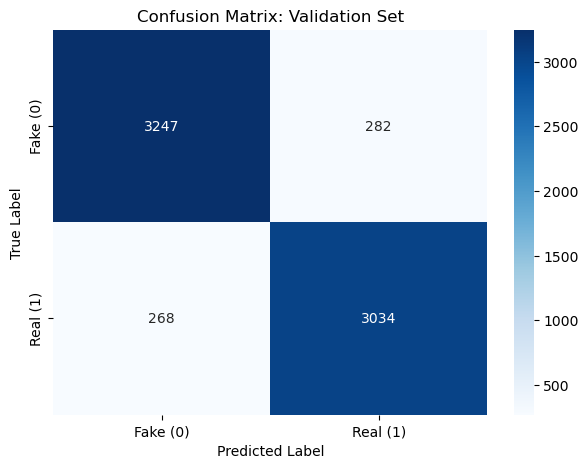